In [1]:
!nvidia-smi

Wed Mar 18 20:53:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import keras as kr
from keras import layers
import seaborn as sb
import sklearn
import tensorflow as tf
import random as rnd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sklearn.set_config(transform_output="pandas")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/My Drive/waste-clasifier/

/content/drive/My Drive/waste-clasifier


In [5]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

In [6]:
train_csv=pd.read_csv("train/_classes.csv")
train_df=pd.DataFrame(train_csv)
test_csv=pd.read_csv("test/_classes.csv")
test_df=pd.DataFrame(test_csv)
valid_csv=pd.read_csv("valid/_classes.csv")
valid_df=pd.DataFrame(valid_csv)

y_train = train_df[classes].values
y_val = valid_df[classes].values
y_test = test_df[classes].values

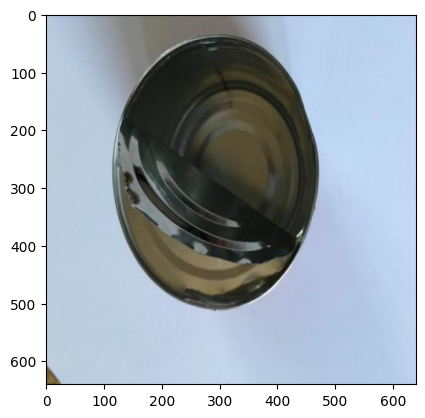

In [7]:
random_idx = rnd.randint(0, len(train_df) - 1)
img_path = os.path.join("train", train_df["filename"][random_idx])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [8]:
vis_df=pd.DataFrame({
    "train":train_df[classes].sum(),
    "test":test_df[classes].sum(),
    "valid":valid_df[classes].sum()
})
vis_df

,train,test,valid
cardboard,275,44,84
glass,352,47,102
metal,284,40,85
paper,423,64,107
plastic,340,44,96
trash,93,14,30


<Axes: xlabel='category', ylabel='count'>

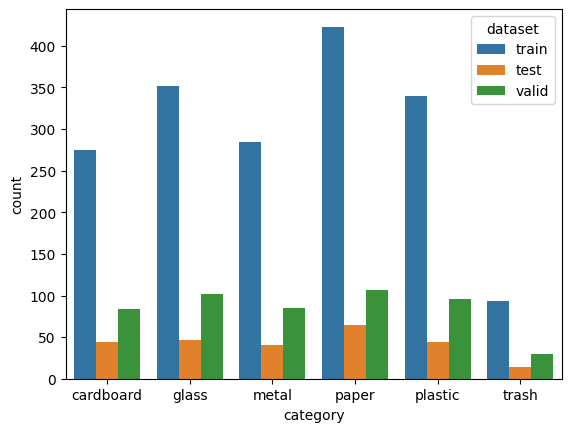

In [9]:
df_plot = vis_df.reset_index().rename(columns={'index': 'category'})
df_melted = df_plot.melt(id_vars='category', var_name='dataset', value_name='count')
sb.barplot(data=df_melted, x='category', y='count', hue='dataset')

In [10]:
datagen = ImageDataGenerator(rescale=1./255)
image_size=128
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="train/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 1767 validated image filenames.


In [11]:
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory="valid/",
    x_col=valid_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 504 validated image filenames.


In [12]:
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="test/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=32,
    class_mode="raw"
)

Found 253 validated image filenames.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

one_hot_labels = train_df[classes].values 
print(one_hot_labels)

train_classes_int = np.argmax(one_hot_labels, axis=1)
print(train_classes_int)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_int),
    y=train_classes_int
)

class_weights_dict = dict(enumerate(class_weights_array))

print("Wyliczone wagi klas:", class_weights_dict)

[[0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 ...
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]
[3 3 3 ... 0 0 0]
Wyliczone wagi klas: {0: np.float64(1.0709090909090908), 1: np.float64(0.8366477272727273), 2: np.float64(1.0369718309859155), 3: np.float64(0.6962174940898345), 4: np.float64(0.8661764705882353), 5: np.float64(3.1666666666666665)}


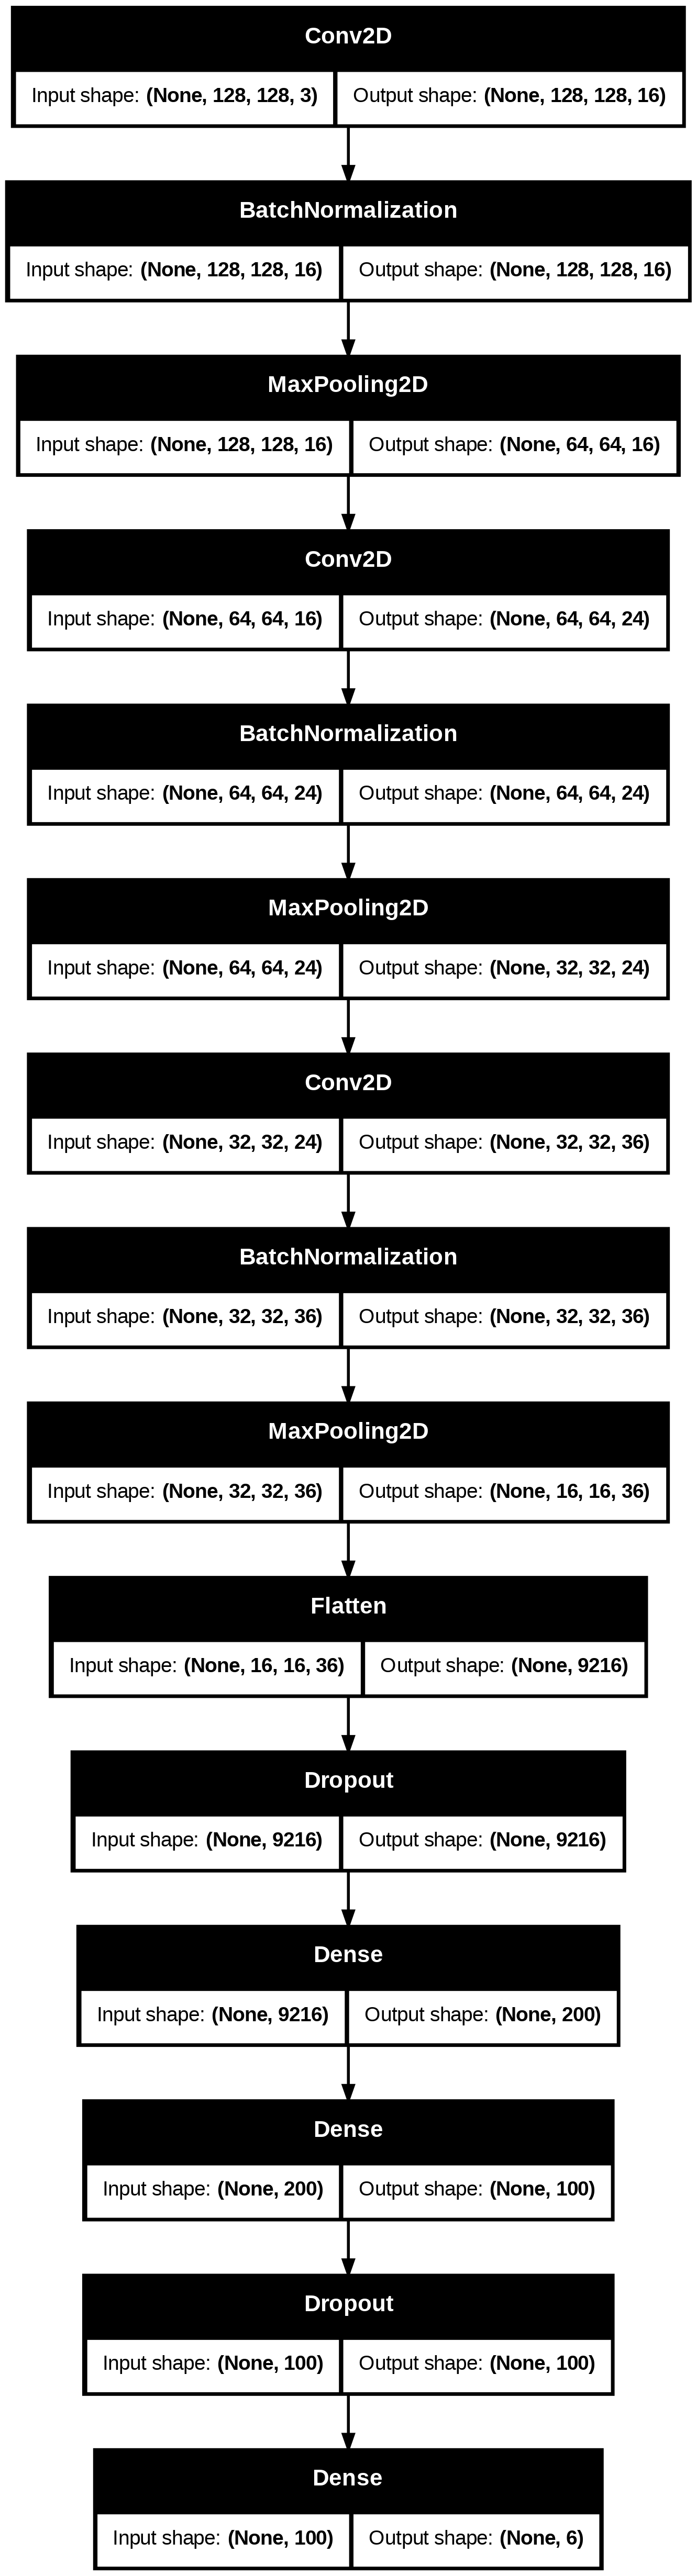

In [20]:
conv_dense=16
model=kr.Sequential(
    [
        layers.Input((image_size,image_size,3)),
        layers.Conv2D(conv_dense, 7, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((3*conv_dense)//2, 5, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((9*conv_dense)//4, 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Flatten(),
        
        layers.Dropout(0.5),

        layers.Dense(200,activation="softplus"),
        layers.Dense(100,activation="tanh"),

        layers.Dropout(0.5),
        
        layers.Dense(6, activation="softmax")
    ]
)

model.build()
kr.utils.plot_model(model, show_shapes=True)


In [ ]:
def make_model(input_shape, conv_dense=16, conv_num=3, num_classes=2):
    inputs = kr.Input(shape=input_shape)

    # Entry block
    #x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(conv_dense, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual
    size=conv_dense
    for i in range(1,conv_num):
        size*=2
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )

        #x = layers.add([x, residual])
        #previous_block_activation = x
        #x = layers.add([x, residual])
        previous_block_activation = x


    size*=2

    x = layers.SeparableConv2D(size, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    """
    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes
    """
    x = layers.Flatten()(x)
    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(num_classes, activation=None)(x)
    return kr.Model(inputs, outputs)


model = make_model(input_shape=(image_size,image_size,3), num_classes=6)
kr.utils.plot_model(model, show_shapes=True)


NameError: name 'xd' is not defined

In [ ]:
"""
def make_model(input_shape, conv_dense=64, conv_num=3, num_classes=2):
    inputs = kr.Input(shape=input_shape)

    # Entry block
    #x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(conv_dense, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual
    size=conv_dense
    for i in range(1,conv_num):
        size*=2
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes
    
    x = layers.Flatten()(x)
    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(num_classes, activation=None)(x)
    return kr.Model(inputs, outputs)


model = make_model(input_shape=(image_size,image_size,3), num_classes=6)
kr.utils.plot_model(model, show_shapes=True)
"""

'\ndef make_model(input_shape, conv_dense=64, conv_num=3, num_classes=2):\n    inputs = kr.Input(shape=input_shape)\n\n    # Entry block\n    #x = layers.Rescaling(1.0 / 255)(inputs)\n    x = layers.Conv2D(conv_dense, 3, strides=2, padding="same")(inputs)\n    x = layers.BatchNormalization()(x)\n    x = layers.Activation("relu")(x)\n\n    previous_block_activation = x  # Set aside residual\n    size=conv_dense\n    for i in range(1,conv_num):\n        size*=2\n        x = layers.Activation("relu")(x)\n        x = layers.SeparableConv2D(size, 3, padding="same")(x)\n        x = layers.BatchNormalization()(x)\n\n        x = layers.Activation("relu")(x)\n        x = layers.SeparableConv2D(size, 3, padding="same")(x)\n        x = layers.BatchNormalization()(x)\n\n        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)\n\n        # Project residual\n        residual = layers.Conv2D(size, 1, strides=2, padding="same")(\n            previous_block_activation\n        )\n        x = la

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 24)     │         9,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 36)     │         7,812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │     1,843,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,884,214 (7.19 MB)

 Trainable params: 1,884,062 (7.19 MB)

 Non-trainable params: 152 (608.00 B)

In [ ]:
epochs = 50
Adam = kr.optimizers.Adam(learning_rate=0.005)
r_lr=kr.callbacks.ReduceLROnPlateau(patience=2, monitor="val_recall",factor=0.7)
e_s=kr.callbacks.EarlyStopping(patience=10, monitor="val_recall")
model.compile(optimizer=Adam,loss="categorical_crossentropy",metrics =['accuracy','recall','precision'])
model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[r_lr,e_s],
    validation_data=valid_generator,
    class_weight=class_weights_dict
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 265ms/step - accuracy: 0.2654 - loss: 2.2393 - precision: 0.2949 - recall: 0.1636 - val_accuracy: 0.2024 - val_loss: 1.9636 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0050
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.2417 - loss: 2.0428 - precision: 0.2900 - recall: 0.1087 - val_accuracy: 0.2063 - val_loss: 2.0173 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0050
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.2722 - loss: 1.8675 - precision: 0.3320 - recall: 0.0973 - val_accuracy: 0.1825 - val_loss: 2.0293 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0050
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.2813 - loss: 1.7883 - precision: 0.4149 - recall: 0.0911 - val_accuracy: 0.2044 - val_loss: 1.7834 - val_precision: 0.3333 - val_recall: 0.0020 - learning_rate: 0.0035
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 

In [24]:
model.save('bad_model50.keras')